# Fine-tuning — PhaseNet

Fine-tunes PhaseNet using the shared local dataset and saves the trained weights and loss history. Architecture-specific settings are defined below.


## Key settings

PhaseNet starts from `instance` weights and uses 30 s windows with peak normalization. Training uses soft P/S/N targets and cross-entropy; dev loss controls early stopping. The baseline weights are saved before fine-tuning for the paired comparison.

## 1. Environment + shared utilities

In [1]:
import sys
sys.path.insert(0, r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion\src\training")
import training_utils as tu          # FIRST import: applies the DLL fix and imports torch
import torch
import numpy as np
import seisbench.models as sbm
import seisbench.generate as sbg
from torch.utils.data import DataLoader
tu.banner()

seisbench 0.12.3 | torch 2.5.1+cu121 | device: cuda


## 2. Configuration

In [2]:
ARCH       = "PhaseNet"
STATIONS   = None         # None = all stations (unbiased); or a list e.g. ["JAMC","ORTC"]
PRETRAINED = "instance"
EPOCHS     = 100
BATCH_SIZE = 64
LR         = 1e-4
SIGMA      = 20
SEED       = 42
PATIENCE   = 6
MIN_DELTA  = 1e-4

torch.manual_seed(SEED); np.random.seed(SEED)
FT_CKPT   = tu.MODELS_DIR / f"{ARCH.lower()}_ft.pt"
BASE_CKPT = tu.MODELS_DIR / f"{ARCH.lower()}_baseline_{PRETRAINED}.pt"
print("Stations:", "ALL" if not STATIONS else STATIONS, "| checkpoint:", FT_CKPT.name)

Stations: ALL | checkpoint: phasenet_ft.pt


## 3. Dataset (train / dev)

In [3]:
data = tu.load_dataset(STATIONS)
train, dev, test = data.train_dev_test()
print()
tu.split_summary(train, "train"); tu.split_summary(dev, "dev")
print(f"  (test reserved for evaluate: {len(test)})")

No filter (all stations): 106580 traces
stations: ['BRJC', 'CBOC', 'CHI', 'DBB', 'GUY2C', 'JAMC', 'MAL', 'NOR', 'ORTC', 'PAL', 'PIZC', 'PRA', 'PTB', 'PTGC', 'QUBC', 'RUS', 'SPBC', 'TAM', 'URE', 'URMC', 'YOT', 'ZAR']

  train: 74600  {'earthquake': 37300, 'noise': 37300}
  dev  : 16414  {'earthquake': 8207, 'noise': 8207}
  (test reserved for evaluate: 15566)


## 4. Base model + baseline snapshot

In [4]:
model = sbm.PhaseNet.from_pretrained(PRETRAINED).to(tu.DEVICE)
print("labels:", model.labels, "| in_samples:", model.in_samples, "| norm:", model.norm)
torch.save(model.state_dict(), BASE_CKPT)
print("baseline saved:", BASE_CKPT.name)

c:\Users\moise\miniconda3\envs\tesismaster\Lib\site-packages\seisbench\models\base.py:952: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_p

labels: PSN | in_samples: 3001 | norm: peak
baseline saved: phasenet_baseline_instance.pt


## 5. Training generators (PhaseNet-specific)

In [5]:
def make_train_gen(subset):
    gen = sbg.GenericGenerator(subset)
    gen.add_augmentations([
        sbg.WindowAroundSample(list(tu.PHASE_DICT.keys()), samples_before=3000,
                               windowlen=6000, selection="random", strategy="variable"),
        sbg.RandomWindow(windowlen=3001, strategy="pad"),
        sbg.Normalize(demean_axis=-1, amp_norm_axis=-1, amp_norm_type="peak"),
        sbg.ChangeDtype(np.float32),
        sbg.ProbabilisticLabeller(label_columns=tu.PHASE_DICT, sigma=SIGMA, dim=0,
                                  model_labels=model.labels),
    ])
    return gen

train_loader = DataLoader(make_train_gen(train), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
dev_loader   = DataLoader(make_train_gen(dev), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("batches -> train:", len(train_loader), " dev:", len(dev_loader))

batches -> train: 1165  dev: 257


## 6. Loss (PhaseNet-specific) + fine-tuning

In [6]:
def loss_fn(out, batch, eps=1e-5):
    # PhaseNet: softmax output over P/S/N channels -> probabilistic cross-entropy
    y = batch["y"]
    h = (y * torch.log(out + eps)).mean(-1).sum(-1)
    return -h.mean()

hist, best, best_ep, reason = tu.fit(model, train_loader, dev_loader, loss_fn,
                                     epochs=EPOCHS, patience=PATIENCE,
                                     min_delta=MIN_DELTA, lr=LR)

epoch 01/100   train=0.0151   dev=0.0139  *best dev*
epoch 02/100   train=0.0139   dev=0.0137  *best dev*
epoch 03/100   train=0.0137   dev=0.0135  *best dev*
epoch 04/100   train=0.0136   dev=0.0134  *best dev*
epoch 05/100   train=0.0134   dev=0.0133  (no improvement 1/6)
epoch 06/100   train=0.0134   dev=0.0134  (no improvement 2/6)
epoch 07/100   train=0.0134   dev=0.0133  *best dev*
epoch 08/100   train=0.0133   dev=0.0134  (no improvement 1/6)
epoch 09/100   train=0.0132   dev=0.0133  (no improvement 2/6)
epoch 10/100   train=0.0132   dev=0.0132  (no improvement 3/6)
epoch 11/100   train=0.0132   dev=0.0132  *best dev*
epoch 12/100   train=0.0132   dev=0.0131  (no improvement 1/6)
epoch 13/100   train=0.0131   dev=0.0132  (no improvement 2/6)
epoch 14/100   train=0.0131   dev=0.0131  (no improvement 3/6)
epoch 15/100   train=0.0131   dev=0.0133  (no improvement 4/6)
epoch 16/100   train=0.0131   dev=0.0132  (no improvement 5/6)
epoch 17/100   train=0.0130   dev=0.0132  (no improv

### Loss curve

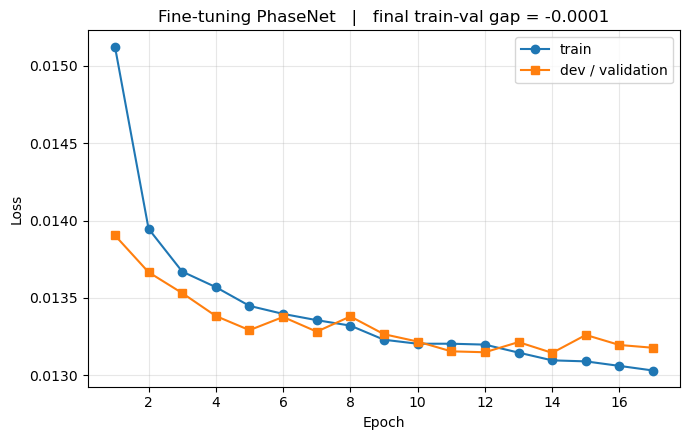

[OK] No sign of overfitting (best dev at epoch 14/17, final gap -0.0001).


In [7]:
tu.plot_loss(hist, ARCH)

## 7. Save fine-tuned weights

In [8]:
torch.save(model.state_dict(), FT_CKPT)
print("fine-tuned saved:", FT_CKPT)
print("baseline (for evaluation):", BASE_CKPT)

fine-tuned saved: M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\models\phasenet_ft.pt
baseline (for evaluation): M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\models\phasenet_baseline_instance.pt
